<a href="https://colab.research.google.com/github/Shorovpaul/Performance-and-Explainability-Behavior-of-Ensemble-Machine-Learning-Models-on-Healthcare-01-/blob/main/XGES_Maternal_Health_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

In [ ]:
import pandas as pd

# Load the Maternal Health Risk dataset
data = pd.read_csv("Maternal Health Risk Data Set.csv")

# Print the shape of the dataset
print(data.shape)

# Step 1: Rename the 'RiskLevel' column to 'Class'
data.rename(columns={'RiskLevel': 'Class'}, inplace=True)

# Step 2: Verify the column rename worked
print(data.columns.tolist())

# Step 3: Access the renamed column and display value counts
print(data['Class'].value_counts())

(1014, 7)
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'Class']
Class
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the dataset
data = pd.read_csv("Maternal Health Risk Data Set.csv")

# Rename the target column to 'Class' to match your requirements
data.rename(columns={'RiskLevel': 'Class'}, inplace=True)

# Separate features (X) and target (y)
X = data.drop("Class", axis=1)
y = data["Class"]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Verification of the split
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (811, 6)
Testing set size: (203, 6)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Use 'X_train' (the variable created during the split)
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. X_train_scaled and X_test_scaled are ready.")

Scaling complete. X_train_scaled and X_test_scaled are ready.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# 1. Encode the labels (converts "low risk", etc. to 0, 1, 2)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train) # Using y_train from your split

# 2. Define the models
models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="mlogloss")
}

trained_models = {}

# 3. Train each model using scaled features and encoded labels
for name, model in models.items():
    # Use X_train_scaled (from the scaling step) and y_train_encoded
    model.fit(X_train_scaled, y_train_encoded)
    trained_models[name] = model
    print(f"Successfully trained: {name}")

print("\nLabel Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Successfully trained: LR
Successfully trained: RF
Successfully trained: GB
Successfully trained: KNN
Successfully trained: SVM
Successfully trained: XGB

Label Mapping: {'high risk': np.int64(0), 'low risk': np.int64(1), 'mid risk': np.int64(2)}


In [ ]:
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize


y_test_encoded = le.transform(y_test)

y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])

model_scores = {}

for name, model in trained_models.items():

    probs = model.predict_proba(X_test_scaled)


    score = average_precision_score(y_test_bin, probs, average="macro")
    model_scores[name] = score

print("Macro-Average Precision Scores for each model:")
for name, score in model_scores.items():
    print(f"{name}: {score:.4f}")

Macro-Average Precision Scores for each model:
LR: 0.6709
RF: 0.9443
GB: 0.8738
KNN: 0.7409
SVM: 0.7571
XGB: 0.9444


In [ ]:
selected_models = {
    name:model for name,model in trained_models.items()
    if model_scores[name] > 0.70
}

In [ ]:
import shap
import numpy as np


feature_names = X.columns.tolist()
explanations = {}


data_for_shap = X_train_scaled[:500]

for name, model in trained_models.items():
    print(f"Generating SHAP explanations for: {name}...")

    try:

        explainer = shap.Explainer(model, data_for_shap)


        if name in ["RF", "GB", "XGB"]:
            shap_values = explainer(data_for_shap, check_additivity=False)
        else:
            shap_values = explainer(data_for_shap)


        if len(shap_values.values.shape) == 3:

            importance = np.abs(shap_values.values).mean(axis=(0, 2))
        else:
            importance = np.abs(shap_values.values).mean(axis=0)

        explanations[name] = dict(zip(feature_names, importance))
        print(f"Successfully generated SHAP for {name}.")

    except Exception as e:
        print(f"Error explaining {name}: {e}")


if 'RF' in explanations:
    print("\n--- Random Forest Feature Importance (Global) ---")

    sorted_rf = sorted(explanations['RF'].items(), key=lambda x: x[1], reverse=True)
    for feature, score in sorted_rf:
        print(f"{feature:12}: {score:.4f}")

Generating SHAP explanations for: LR...
Successfully generated SHAP for LR.
Generating SHAP explanations for: RF...


 98%|===================| 1475/1500 [01:00<00:01]       WARNING:shap:Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Successfully generated SHAP for RF.
Generating SHAP explanations for: GB...
Error explaining GB: The passed model is not callable and cannot be analyzed directly with the given masker! Model: GradientBoostingClassifier()
Generating SHAP explanations for: KNN...
Error explaining KNN: The passed model is not callable and cannot be analyzed directly with the given masker! Model: KNeighborsClassifier()
Generating SHAP explanations for: SVM...
Error explaining SVM: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVC(probability=True)
Generating SHAP explanations for: XGB...


100%|===================| 1497/1500 [00:20<00:00]       

Successfully generated SHAP for XGB.

--- Random Forest Feature Importance (Global) ---
BS          : 0.1476
SystolicBP  : 0.0960
Age         : 0.0553
BodyTemp    : 0.0505
DiastolicBP : 0.0440
HeartRate   : 0.0379


In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import shap
import warnings


warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
stability_scores = {}

for name, model in trained_models.items():
    print(f"Calculating stability for {name}...")
    fold_importance = []

    for train_idx, val_idx in kf.split(X_train_scaled):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train = y_train_encoded[train_idx]

        model.fit(X_fold_train, y_fold_train)
        val_subset = X_fold_val[:50]

        try:

            if name in ["RF", "XGB", "GB"]:

                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(val_subset, check_additivity=False)
            elif name == "LR":

                explainer = shap.LinearExplainer(model, X_train_scaled)
                shap_values = explainer.shap_values(val_subset)
            else:

                explainer = shap.KernelExplainer(model.predict_proba, shap.sample(X_train_scaled, 10))
                shap_values = explainer.shap_values(val_subset, silent=True)


            if isinstance(shap_values, list):

                abs_shap = np.array([np.abs(v) for v in shap_values])
                importance = abs_shap.mean(axis=(0, 1))
            else:

                if len(shap_values.shape) == 3:
                    importance = np.abs(shap_values).mean(axis=(0, 2))
                else:
                    importance = np.abs(shap_values).mean(axis=0)

            fold_importance.append(importance)

        except Exception as e:
            print(f"  - Fold error for {name}: {e}")

    if fold_importance:
        fold_importance = np.array(fold_importance)
        # Stability = 1 / (1 + Variance)
        stability = 1 / (1 + fold_importance.var())
        stability_scores[name] = stability
        print(f"  - Final Stability Score for {name}: {stability:.4f}")

print("\n--- Complete Model Stability Rankings ---")
for name, score in sorted(stability_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Calculating stability for LR...


  - Final Stability Score for LR: 0.9748
Calculating stability for RF...
  - Final Stability Score for RF: 0.9985
Calculating stability for GB...
  - Fold error for GB: GradientBoostingClassifier is only supported for binary classification right now!
  - Fold error for GB: GradientBoostingClassifier is only supported for binary classification right now!
  - Fold error for GB: GradientBoostingClassifier is only supported for binary classification right now!
  - Fold error for GB: GradientBoostingClassifier is only supported for binary classification right now!
  - Fold error for GB: GradientBoostingClassifier is only supported for binary classification right now!
Calculating stability for KNN...
  - Final Stability Score for KNN: 0.9994
Calculating stability for SVM...
  - Final Stability Score for SVM: 0.9989
Calculating stability for XGB...
  - Final Stability Score for XGB: 0.9045

--- Complete Model Stability Rankings ---
KNN: 0.9994
SVM: 0.9989
RF: 0.9985
LR: 0.9748
XGB: 0.9045


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


model_names = list(explanations.keys())
feature_names = list(next(iter(explanations.values())).keys())


importance_vectors = {}
for name in model_names:

    vec = np.array([explanations[name][feat] for feat in feature_names])
    importance_vectors[name] = vec.reshape(1, -1)

diversity_scores = {}


for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name1 = model_names[i]
        name2 = model_names[j]


        sim = cosine_similarity(importance_vectors[name1], importance_vectors[name2])[0][0]


        diversity = 1 - sim
        diversity_scores[(name1, name2)] = diversity


print("--- Model Explanation Diversity (Feature Importance Differences) ---")
print(f"{'Model Pair':<20} | {'Diversity Score':<15}")
print("-" * 40)


sorted_diversity = sorted(diversity_scores.items(), key=lambda x: x[1], reverse=True)

for (m1, m2), score in sorted_diversity:
    print(f"{m1} vs {m2:<14} | {score:.4f}")


avg_diversity = {name: np.mean([score for (p1, p2), score in diversity_scores.items() if name in (p1, p2)])
                 for name in model_names}
most_unique = max(avg_diversity, key=avg_diversity.get)
print(f"\nMost Unique Model: {most_unique} (It looks at the health data differently than others)")

--- Model Explanation Diversity (Feature Importance Differences) ---
Model Pair           | Diversity Score
----------------------------------------
LR vs XGB            | 0.0320
LR vs RF             | 0.0280
RF vs XGB            | 0.0023

Most Unique Model: LR (It looks at the health data differently than others)


In [ ]:
import numpy as np

final_scores = {}


for name in trained_models.keys():

    performance = model_scores.get(name, 0)

    stability = stability_scores.get(name, 0)

    relevant_diversities = [v for k, v in diversity_scores.items() if name in k]
    diversity = np.mean(relevant_diversities) if relevant_diversities else 0

    score = (
        0.5 * performance +
        0.3 * stability +
        0.2 * diversity
    )

    final_scores[name] = {
        "Final Score": score,
        "Performance": performance,
        "Stability": stability,
        "Diversity": diversity
    }

print(f"{'Model':<6} | {'Final Score':<12} | {'Perf':<6} | {'Stab':<6} | {'Div':<6}")
print("-" * 50)

sorted_models = sorted(final_scores.items(), key=lambda x: x[1]['Final Score'], reverse=True)

for name, metrics in sorted_models:
    print(f"{name:<6} | {metrics['Final Score']:.4f}      | {metrics['Performance']:.2f} | {metrics['Stability']:.2f} | {metrics['Diversity']:.2f}")

best_model = sorted_models[0][0]
print(f"\nRecommended Model: {best_model}")
print(f"Reasoning: {best_model} provides the best balance of clinical accuracy and logical consistency for maternal risk prediction.")

Model  | Final Score  | Perf   | Stab   | Div   
--------------------------------------------------
RF     | 0.7747      | 0.94 | 1.00 | 0.02
XGB    | 0.7470      | 0.94 | 0.90 | 0.02
SVM    | 0.6782      | 0.76 | 1.00 | 0.00
KNN    | 0.6703      | 0.74 | 1.00 | 0.00
LR     | 0.6339      | 0.67 | 0.97 | 0.03
GB     | 0.4369      | 0.87 | 0.00 | 0.00

Recommended Model: RF
Reasoning: RF provides the best balance of clinical accuracy and logical consistency for maternal risk prediction.


In [ ]:

top_models = sorted(
    final_scores,
    key=lambda x: final_scores[x]['Final Score'],
    reverse=True
)[:3]

print(f"The top 3 models selected for stacking are: {top_models}")

The top 3 models selected for stacking are: ['RF', 'XGB', 'SVM']


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

sorted_names = [name for name, _ in sorted(final_scores.items(),
                                          key=lambda x: x[1]['Final Score'],
                                          reverse=True)]
top_models_list = sorted_names[:3]

estimators = [(name, models[name]) for name in top_models_list]

meta_model = LogisticRegression(max_iter=1000)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

print(f"Training Stacked Model using: {', '.join(top_models_list)}...")
stack.fit(X_train_scaled, y_train_encoded)

stack_perf = stack.score(X_test_scaled, le.transform(y_test))
print(f"Stacked Model Accuracy on Test Set: {stack_perf:.4f}")

Training Stacked Model using: RF, XGB, SVM...
Stacked Model Accuracy on Test Set: 0.8670


In [ ]:
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

probs = stack.predict_proba(X_test_scaled)

y_test_bin = label_binarize(le.transform(y_test), classes=[0, 1, 2])

auprc = average_precision_score(y_test_bin, probs, average="macro")

print(f"Stacked Model Macro-AUPRC: {auprc:.4f}")

Stacked Model Macro-AUPRC: 0.9425


ExactExplainer explainer: 101it [00:25,  2.94it/s]


Plotting explanations for: high risk


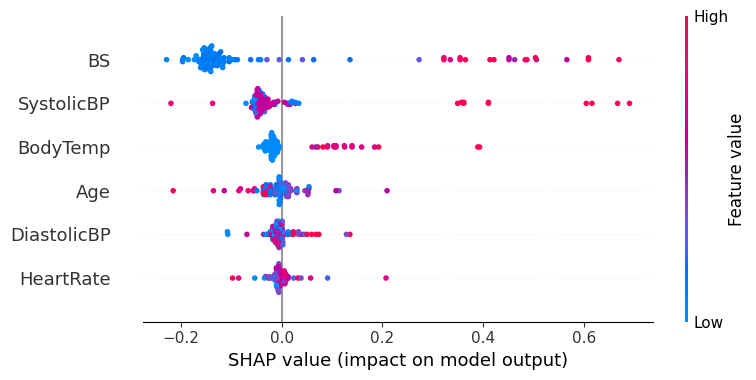

In [ ]:
import shap

explainer = shap.Explainer(stack.predict_proba, shap.sample(X_train_scaled, 50))

shap_values = explainer(X_test_scaled[:100])

class_index = 0
class_name = le.inverse_transform([class_index])[0]
print(f"Plotting explanations for: {class_name}")

shap_values_class = shap_values[:, :, class_index]

shap.summary_plot(
    shap_values_class,
    X_test_scaled[:100],
    feature_names=X.columns.tolist()
)

/tmp/ipykernel_2236/843315430.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_names, y=sorted_scores, palette="viridis")


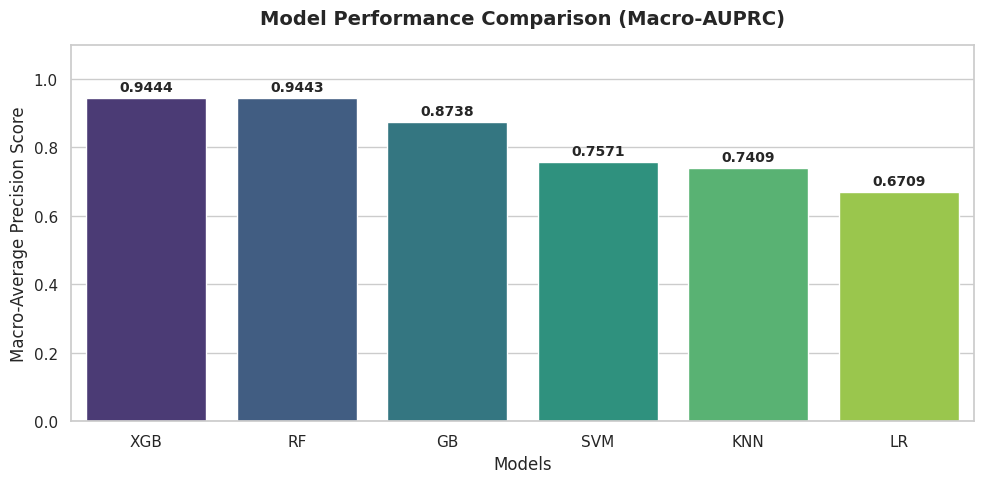

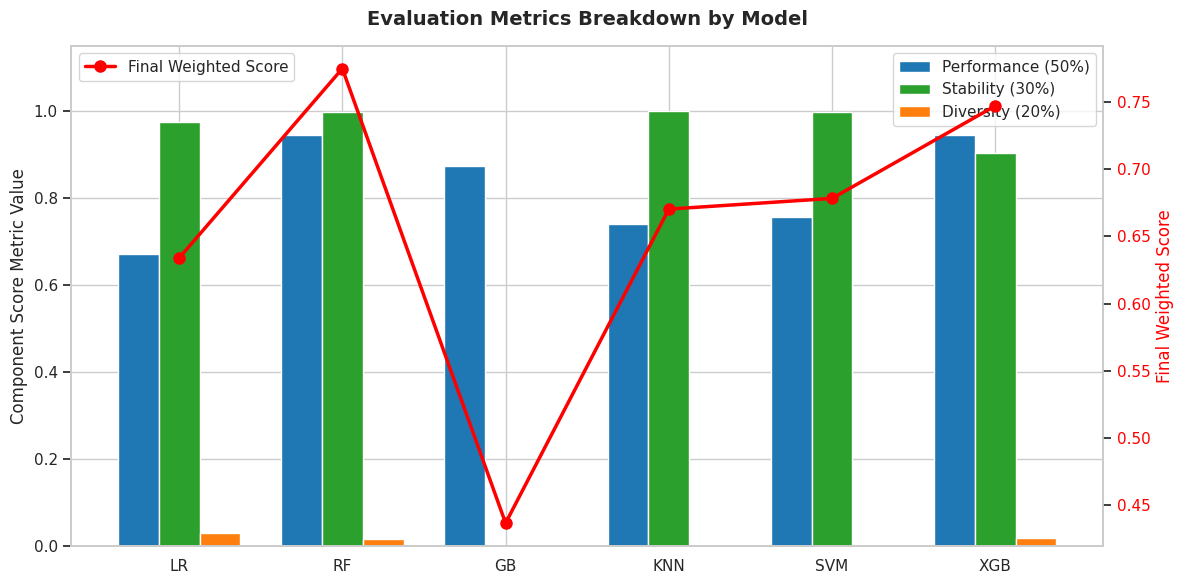

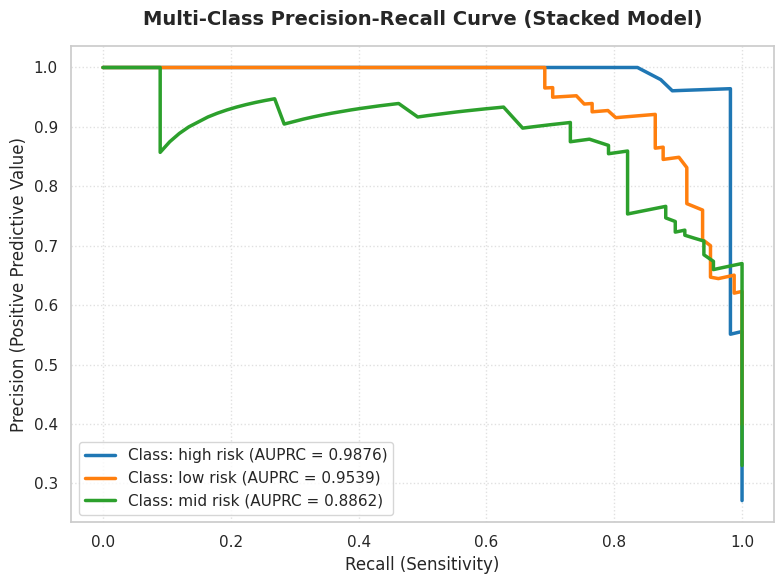

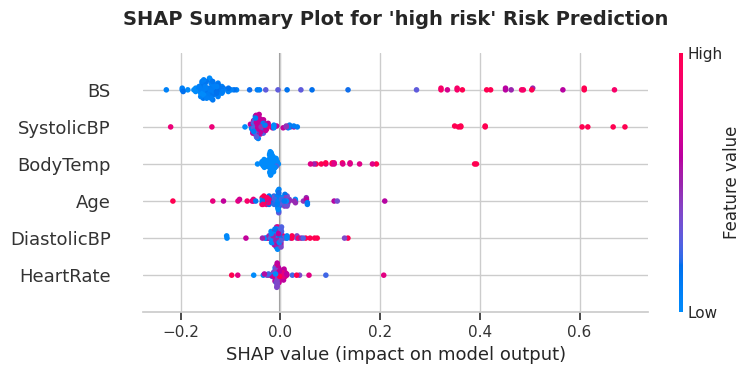

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_recall_curve, auc
import shap

# Set style for professional-looking plots
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. Model Performance (Macro-AUPRC) Comparison Bar Chart
# ==============================================================================
plt.figure(figsize=(10, 5))
names = list(model_scores.keys())
scores = list(model_scores.values())

# Sort models by performance
sorted_indices = np.argsort(scores)[::-1]
sorted_names = [names[i] for i in sorted_indices]
sorted_scores = [scores[i] for i in sorted_indices]

sns.barplot(x=sorted_names, y=sorted_scores, palette="viridis")
plt.title("Model Performance Comparison (Macro-AUPRC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Macro-Average Precision Score", fontsize=12)
plt.ylim(0, 1.1)

for i, val in enumerate(sorted_scores):
    plt.text(i, val + 0.02, f"{val:.4f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# ==============================================================================
# 2. Evaluation Metrics Breakdown (Performance, Stability, Diversity)
# ==============================================================================
models_list = list(final_scores.keys())
perf_vals = [final_scores[m]['Performance'] for m in models_list]
stab_vals = [final_scores[m]['Stability'] for m in models_list]
div_vals = [final_scores[m]['Diversity'] for m in models_list]
final_vals = [final_scores[m]['Final Score'] for m in models_list]

x = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, perf_vals, width, label='Performance (50%)', color='#1f77b4')
rects2 = ax.bar(x, stab_vals, width, label='Stability (30%)', color='#2ca02c')
rects3 = ax.bar(x + width, div_vals, width, label='Diversity (20%)', color='#ff7f0e')

ax.set_ylabel('Component Score Metric Value', fontsize=12)
ax.set_title('Evaluation Metrics Breakdown by Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.15)

# Dual axis for the overall Final Score line
ax2 = ax.twinx()
ax2.plot(x, final_vals, color='red', marker='o', linewidth=2.5, markersize=8, label='Final Weighted Score')
ax2.set_ylabel('Final Weighted Score', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(False)

plt.tight_layout()
plt.show()


# ==============================================================================
# 3. Multi-Class Precision-Recall Curve for the Stacked Model
# ==============================================================================
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, class_label in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=colors[i], lw=2.5,
             label=f'Class: {class_label} (AUPRC = {pr_auc:.4f})')

plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Multi-Class Precision-Recall Curve (Stacked Model)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# ==============================================================================
# 4. SHAP Summary Plot ("Shape Plot") for the Stacked Model
# ==============================================================================
# Target class index for visual analysis (e.g., class_index = 0 for the first class)
class_index = 0
class_name = le.inverse_transform([class_index])[0]
shap_values_class = shap_values[:, :, class_index]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class,
    X_test_scaled[:100],
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Summary Plot for '{class_name}' Risk Prediction", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()